# Perceptron Implementation


In [ ]:
import numpy as np
# input
X = np.array( ((1,1), (1, 0), (0,1), (0,0)) )
print(X)


[[1 1]
 [1 0]
 [0 1]
 [0 0]]


The input is specified as a 4x2-matrix. This means that we collect all input examples in a so-called *batch*.
The following weights and threshold implement the AND function. We compute the output according to

\begin{align}
y = f_{ \mathbf{w}}(\mathbf{x}) = \begin{cases}1 & \text{if } \mathbf{w} \cdot \mathbf{x} + b \geq 0\\0 & \text{otherwise}\end{cases}
\end{align}


In [ ]:
# Set the weight and bias values
# # weights and threshold
weights = np.array([1, 1])
threshold = -1.5
weights, threshold
# Compute output of perceptron to get the correct output $(1,0,0,0)$
# compute output
net = np.dot(X,weights)
output = np.where(net + threshold >= 0, 1, 0)
print(output)

[1 0 0 0]


# Perceptron Learning

In [ ]:
# Let us implement the learning algorithm for the simple perceptron.

# We first import NumPy and specify the input array and the target array.
import numpy as np

# INPUT/TARGET ------------------------------------------------------------
# input
X = np.array( ((1,1), (1, 0), (0,1), (0,0)) )
# target
T = np.array([1,0,0,0])
X, T

(array([[1, 1],
        [1, 0],
        [0, 1],
        [0, 0]]),
 array([1, 0, 0, 0]))

In [ ]:
# We set the initial weights and threshold/bias to zero.
# INITIAL WEIGHTS/BIAS -------------------------------------------
W_init = np.array([0,0])
b_init = 0
W_init, b_init
# We extend the input array and we include the bias in the weight matrix.
# EXTENDED INPUT ----------------------------------------------------------
W = np.append(W_init,b_init)
X_ext = np.hstack((X,np.ones((4,1))))
W, X_ext

(array([0, 0, 0]),
 array([[1., 1., 1.],
        [1., 0., 1.],
        [0., 1., 1.],
        [0., 0., 1.]]))

 Now let us implement the learning rule according to

\begin{align}
\mathbf{w}^{t+1} \Leftarrow \mathbf{w}^{t}+ \Delta \mathbf{w}_i \\
\Delta\mathbf{w}_i = \alpha \left( y_{target} - y_{predicted}\right)x_i
\end{align}

assuming learning rate  equal to 1.

In [ ]:
 # PERCEPTRON LEARNING -------------------------------------------------------
epochs = 7 #number of epochs

for n in range(epochs):
    for i in range(len(X_ext)):
        y_i = np.where(np.dot(X_ext[i,:],W) >= 0, 1, 0)
        W = W + (T[i]-y_i)*X_ext[i,:]
    print(W)
y = np.where(np.dot(X_ext,W) >= 0, 1, 0)
#  Let us look at the target and the output and the weights found by the algorithm.
print(T)
print(y)
print(W)

[-1.  0. -1.]
[-1.  0. -2.]
[ 0.  0. -2.]
[ 0.  1. -2.]
[ 0.  1. -3.]
[ 1.  1. -3.]
[ 1.  2. -3.]
[1 0 0 0]
[1 0 0 0]
[ 1.  2. -3.]


# Display decision boundaries for AND

Training Perceptron for AND


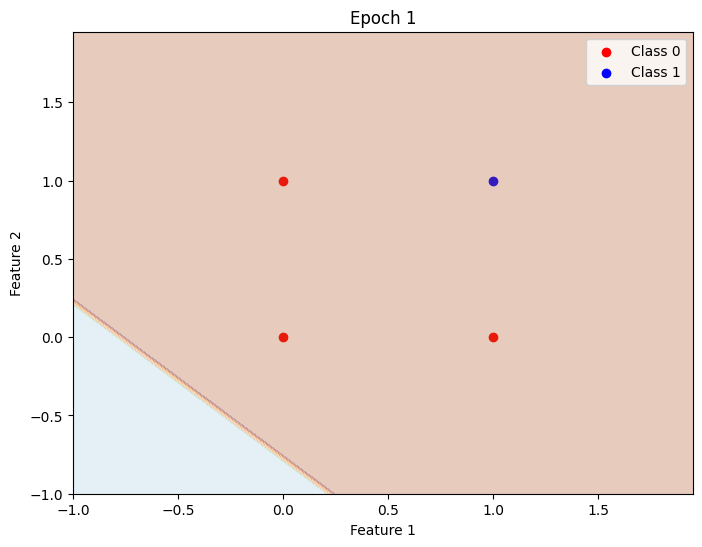

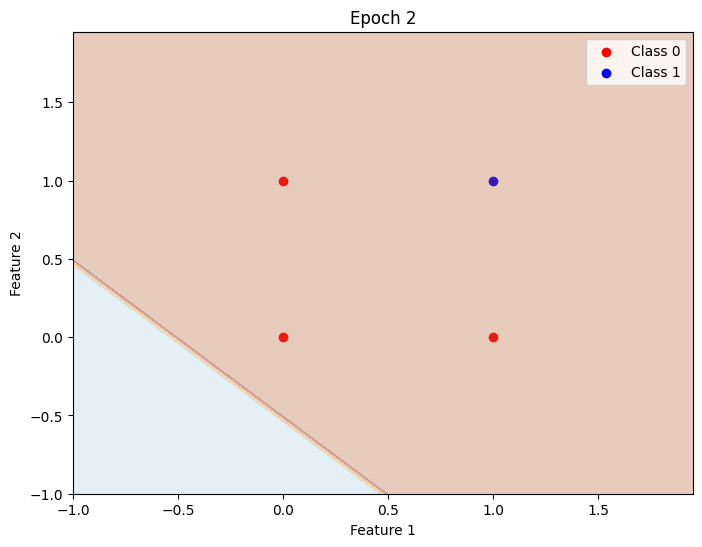

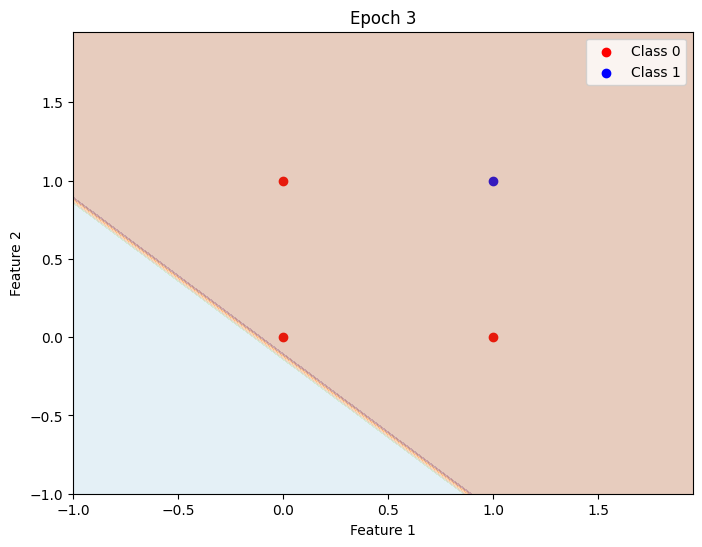

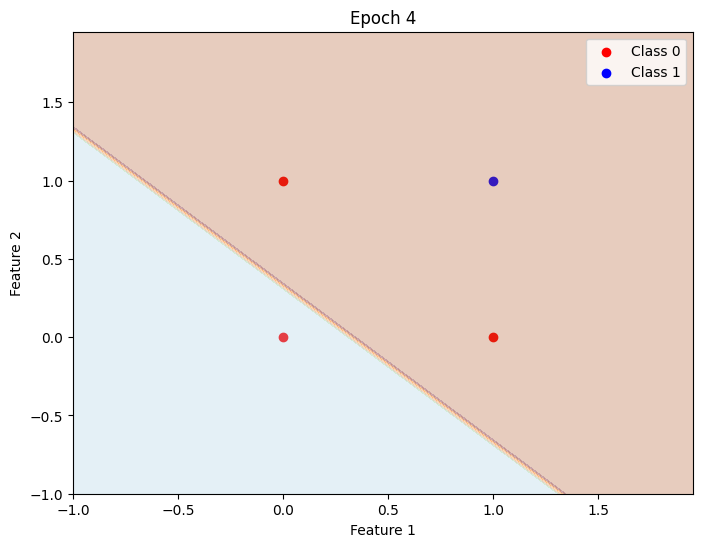

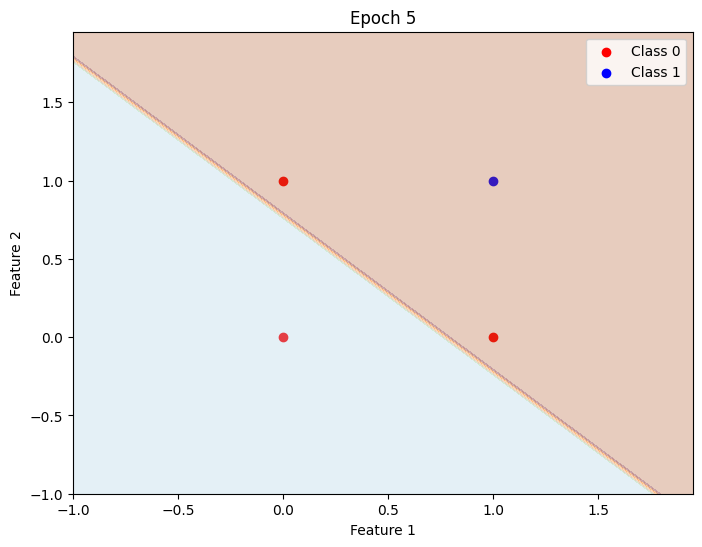

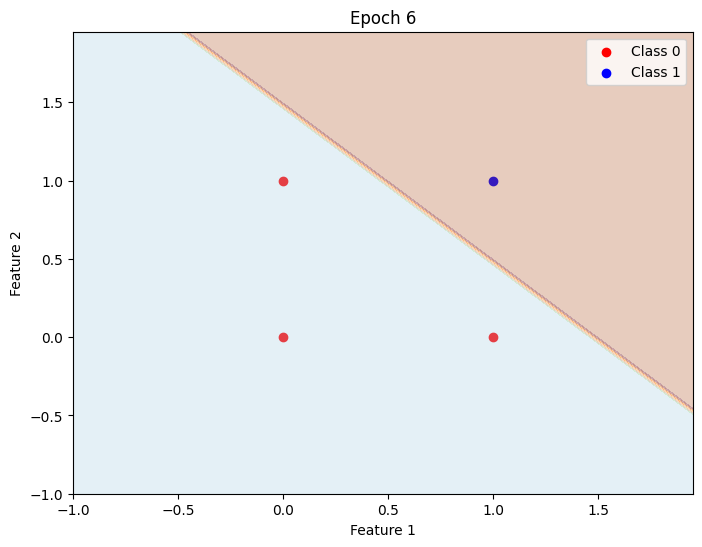

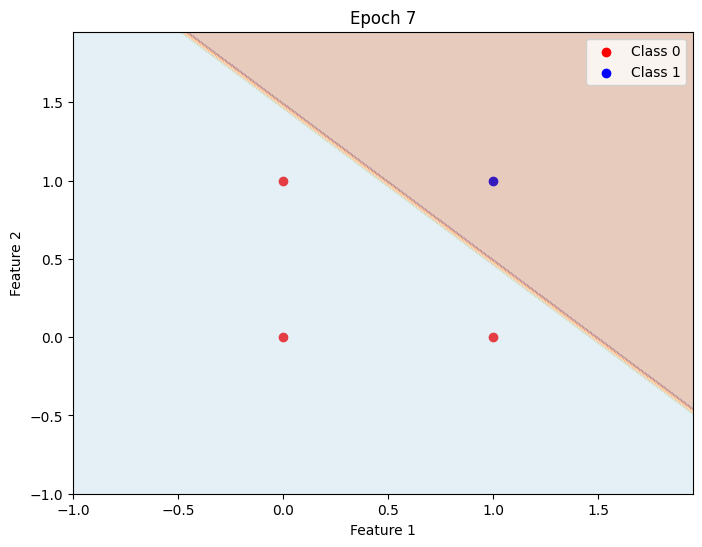

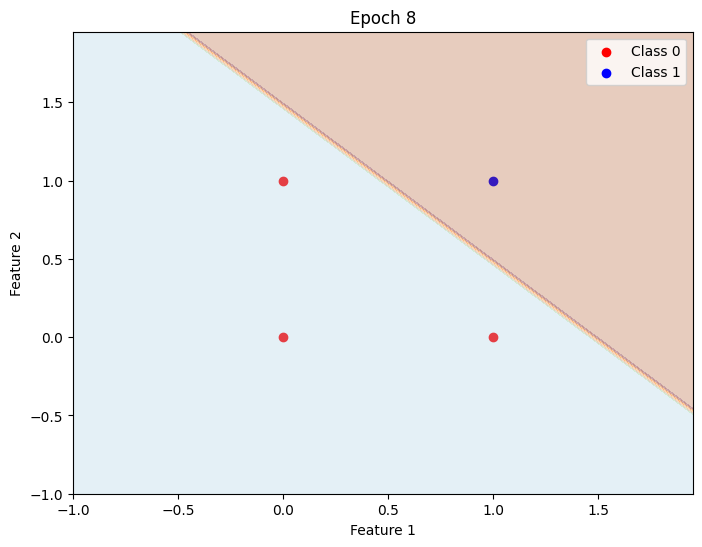

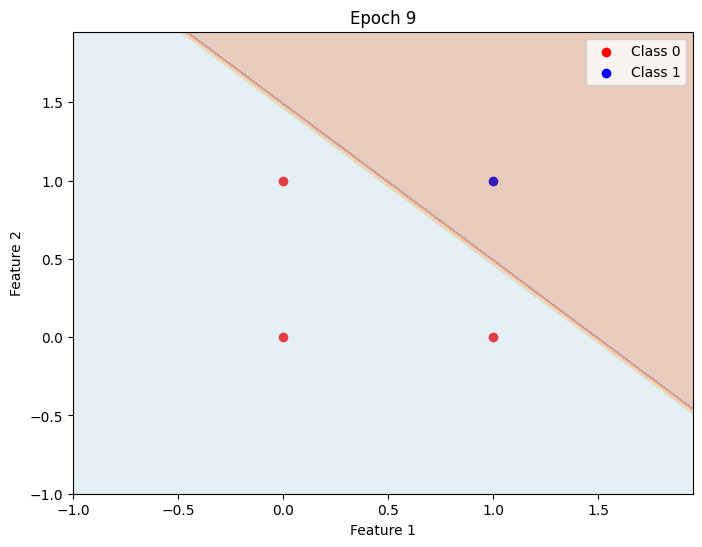

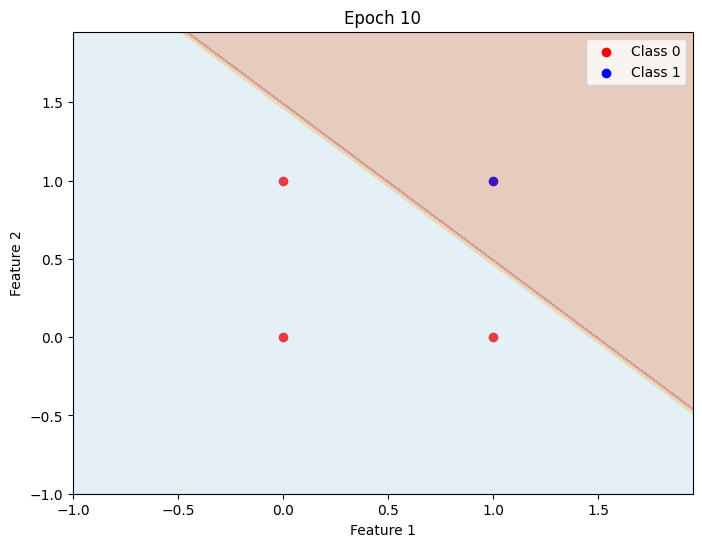

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def predict(X, weights):
    return np.where(np.dot(X, weights[1:]) + weights[0] >= 0, 1, 0)

def plot_decision_boundary(X, y, weights, epoch):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

    # Plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    Z = predict(np.c_[xx.ravel(), yy.ravel()], weights)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.title(f"Epoch {epoch + 1}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

def perceptron_learning(X, y, epochs=10, learning_rate=0.1):
    weights = np.ones(X.shape[1] + 1)  # Initialize weights and bias

    for epoch in range(epochs):
        for i in range(len(X)):
            prediction = predict(X[i].reshape(1, -1), weights)
            error = y[i] - prediction
            weights[1:] += learning_rate * error * X[i]
            weights[0] += learning_rate * error.item()  # Update bias term

        # Plot decision boundary at each epoch
        plot_decision_boundary(X, y, weights, epoch)

# Define datasets
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

# Train and plot for AND
print("Training Perceptron for AND")
perceptron_learning(X_and, y_and)

# Group work

# XOR Implementation using Tensorflow

In [ ]:
## Tensorflow Code
# We can implement the same simple MLP that computes the XOR function with the deep learning library **Tensorflow**.
# We set up the input data and the target data, corresponding to the XOR function.
import numpy as np
import tensorflow
import tensorflow as tf

# INPUT/TARGET
# input
X = np.array( ((1,1), (1, 0), (0,1), (0,0)) )
# target
T = np.array([0,1,1,0])

print(X)
print(T)

[[1 1]
 [1 0]
 [0 1]
 [0 0]]
[0 1 1 0]


In [ ]:
# Use Tensorflow's sequential mode and 'dense' layer to build a FNN.
'''
tf.keras.layers.Dense(
    units, activation=None, use_bias=True,
    kernel_initializer='glorot_uniform',
    bias_initializer='zeros', kernel_regularizer=None,
    bias_regularizer=None, activity_regularizer=None, kernel_constraint=None,
    bias_constraint=None, **kwargs
)
'''

model = tensorflow.keras.Sequential()
model.add(tensorflow.keras.layers.Input(shape=(2,))) # New Input layer
model.add(tensorflow.keras.layers.Dense(2, activation='relu')) # Removed input_shape from here
model.add(tensorflow.keras.layers.Dense(1))
# Look at model's weights and output.
# model weights
model.get_weights()

[array([[0.98258126, 0.6906705 ],
        [0.14275157, 0.4979273 ]], dtype=float32),
 array([0., 0.], dtype=float32),
 array([[-0.10833228],
        [-0.07956553]], dtype=float32),
 array([0.], dtype=float32)]

In [ ]:
# model output
model(X)

<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
array([[-0.21648127],
       [-0.16139883],
       [-0.05508245],
       [ 0.        ]], dtype=float32)>

In [ ]:
# Now, the 'original' MLP that implements the XOR function uses the binary threshold activation function which we have to define as follows
from tensorflow.keras.layers import Activation

# custom activation function
def binary_activation(x):
    return  tf.keras.activations.relu(tf.math.sign(x))

In [ ]:
# Then, we set the weights and define the custom model
# set custom weights
hidden_weights = tf.constant_initializer([[1, -1], [1, -1]])
hidden_bias = tf.constant_initializer([-0.5, 1.5])
out_weights = tf.constant_initializer([1, 1])
out_bias = tf.constant_initializer([-1.5])

# define model
model = tensorflow.keras.Sequential()
model.add(tensorflow.keras.layers.Dense(2,
                                        activation=Activation(binary_activation),
                                        kernel_initializer=hidden_weights,
                                        bias_initializer=hidden_bias,
                                        input_shape=(2,)))
model.add(tensorflow.keras.layers.Dense(1,
                                        activation=Activation(binary_activation),
                                        kernel_initializer=out_weights,
                                        bias_initializer=out_bias))
# Inspecting the model's weights and output we see that the XOR function is computed correctly with that set of weights.
# model weights
model.get_weights()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[array([[ 1., -1.],
        [ 1., -1.]], dtype=float32),
 array([-0.5,  1.5], dtype=float32),
 array([[1.],
        [1.]], dtype=float32),
 array([-1.5], dtype=float32)]

In [ ]:
# model output
model(X)

<tf.Tensor: shape=(4, 1), dtype=float32, numpy=
array([[0.],
       [1.],
       [1.],
       [0.]], dtype=float32)>

# Learn XOR

Training Neural Network for XOR with Two Neurons


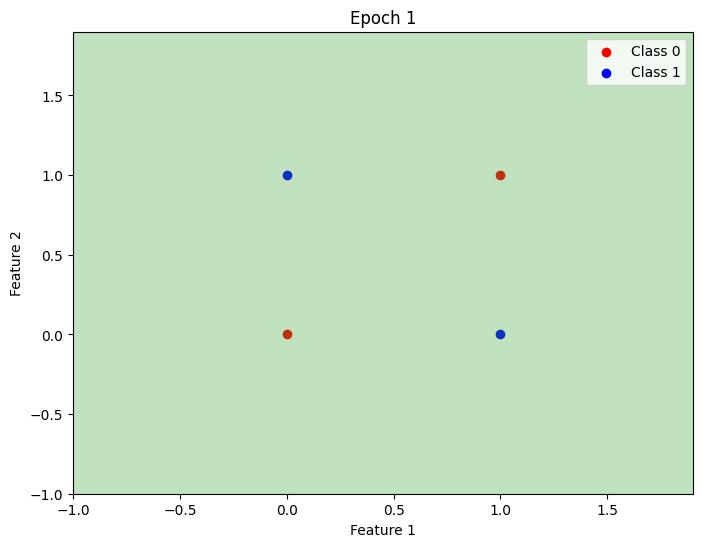

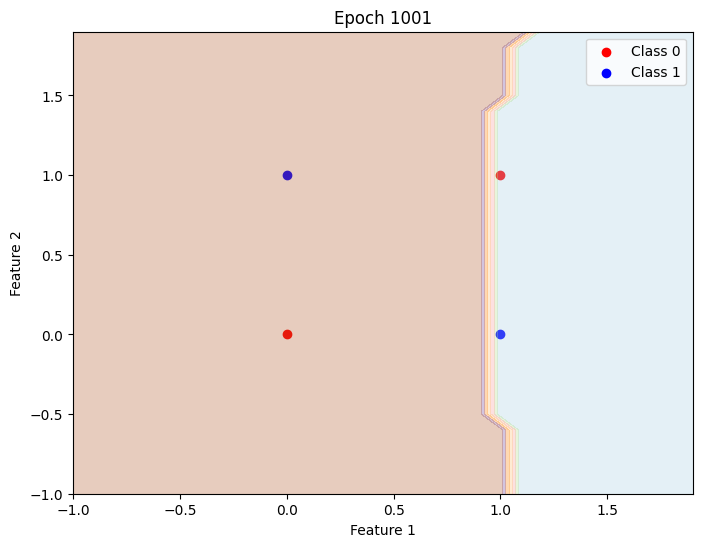

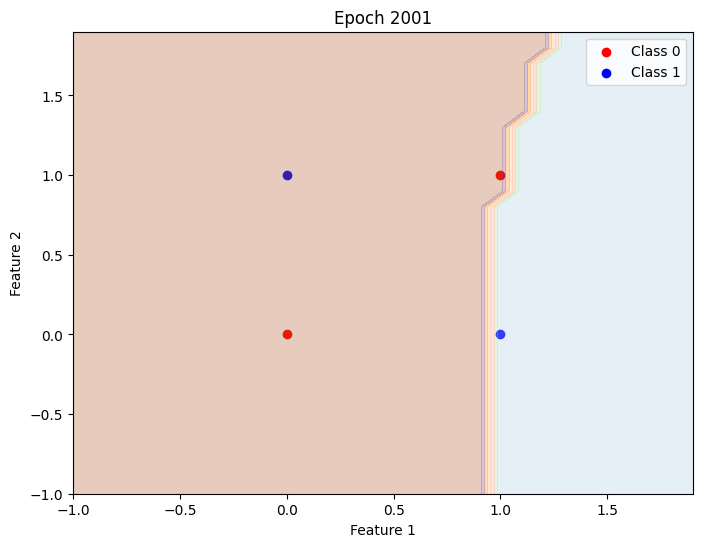

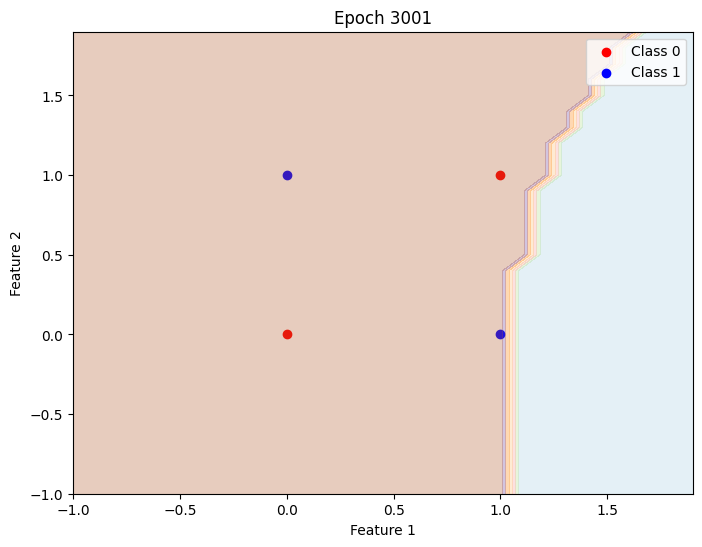

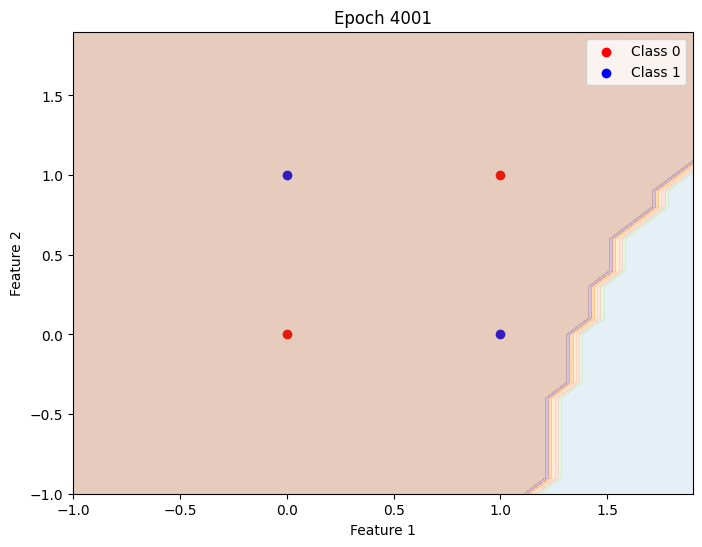

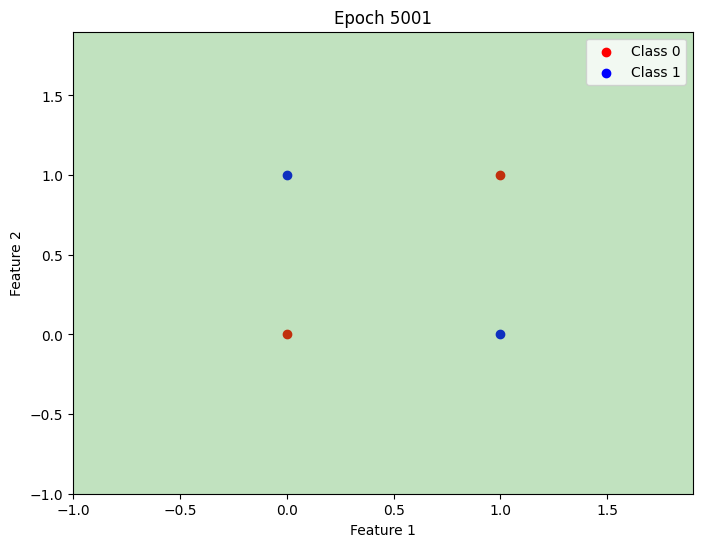

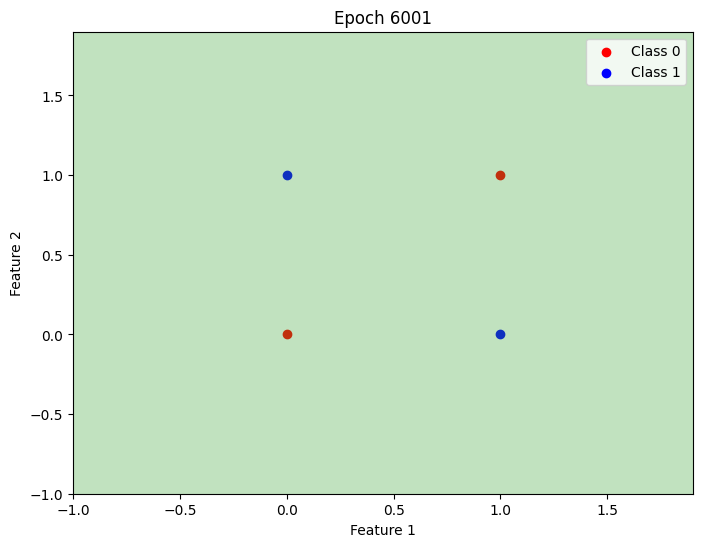

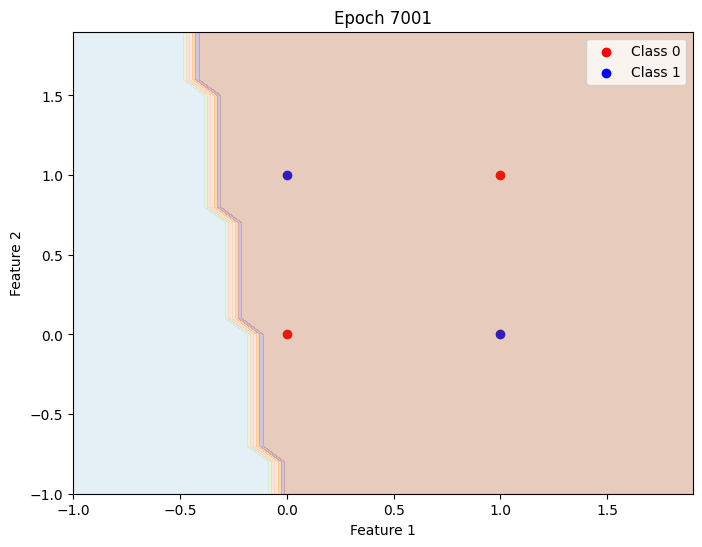

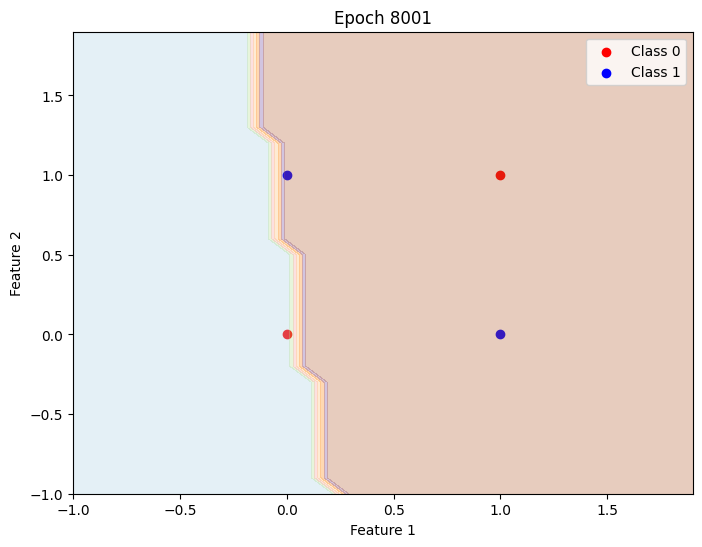

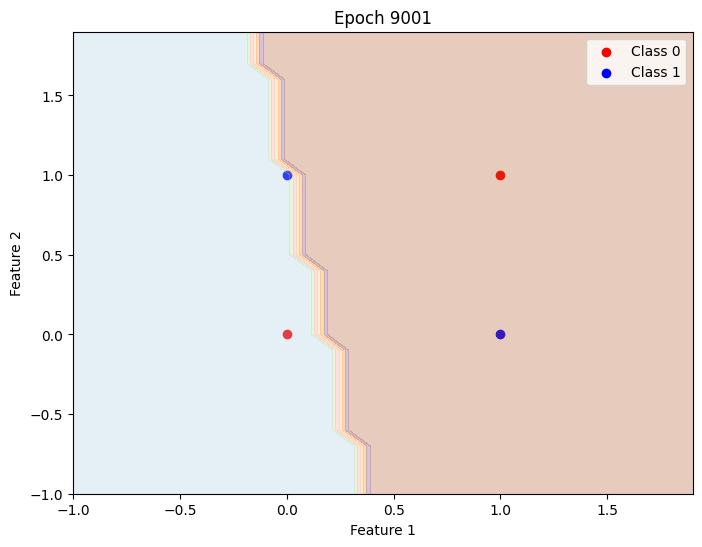

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def predict(X, weights1, weights2):
    hidden_input = np.dot(X, weights1)
    hidden_output = sigmoid(hidden_input)
    final_input = np.dot(hidden_output, weights2)
    final_output = sigmoid(final_input)
    return final_output

def plot_decision_boundary(X, y, weights1, weights2, epoch):
    plt.figure(figsize=(8, 6))
    y = y.flatten()  # Flatten y to make it 1D

    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

    # Plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                         np.arange(y_min, y_max, 0.1))

    Z = predict(np.c_[xx.ravel(), yy.ravel()], weights1, weights2)
    Z = np.where(Z >= 0.5, 1, 0)  # Threshold to convert to binary output
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.title(f"Epoch {epoch + 1}")
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

def train(X, y, epochs=10000, learning_rate=0.05):
    # Initialize weights for both layers
    input_layer_neurons = X.shape[1]
    hidden_layer_neurons = 2
    output_neuron = 1

    weights1 = np.random.uniform(size=(input_layer_neurons, hidden_layer_neurons))
    weights2 = np.random.uniform(size=(hidden_layer_neurons, output_neuron))

    for epoch in range(epochs):
        # Forward pass
        hidden_input = np.dot(X, weights1)
        hidden_output = sigmoid(hidden_input)
        final_input = np.dot(hidden_output, weights2)
        final_output = sigmoid(final_input)

        # Backpropagation
        error = y - final_output
        d_output = error * sigmoid_derivative(final_output)
        error_hidden_layer = d_output.dot(weights2.T)
        d_hidden_layer = error_hidden_layer * sigmoid_derivative(hidden_output)

        # Update weights
        weights2 += hidden_output.T.dot(d_output) * learning_rate
        weights1 += X.T.dot(d_hidden_layer) * learning_rate

        # Plot decision boundary every 1000 epochs
        if epoch % 1000 == 0:
            plot_decision_boundary(X, y, weights1, weights2, epoch)

# Define XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

# Train and plot for XOR using a neural network with two neurons
print("Training Neural Network for XOR with Two Neurons")
train(X_xor, y_xor)


# Example of using tf to classify a dataset

In [ ]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Load and preprocess data
data = load_iris()
X = data.data
y = data.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse=False)
y = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape[1])
# Build the model
model = Sequential([
    Dense(50, activation='relu', input_shape=(X_train.shape[1],)),
    # Dense(10, activation='relu'),
    Dense(3, activation='softmax')
])
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test accuracy: {accuracy}')


4
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.2721 - loss: 1.7349 - val_accuracy: 0.2500 - val_loss: 1.4360
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2656 - loss: 1.1880 - val_accuracy: 0.4583 - val_loss: 1.0930
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6055 - loss: 1.0447 - val_accuracy: 0.6250 - val_loss: 0.9805
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6094 - loss: 0.9831 - val_accuracy: 0.4583 - val_loss: 0.9436
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6654 - loss: 0.9238 - val_accuracy: 0.8750 - val_loss: 0.8733
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7786 - loss: 0.8745 - val_accuracy: 0.7500 - val_loss: 0.8419
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8086 - loss: 0.8369 - val_accuracy: 0.8333 - val_loss: 0.7740
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8190 - loss: 0.7957 - val_accuracy: 0.9167 - val_loss: 0.7644
Epo